# Получение информации по поверке средств измерения в системе "Аршин" через API

Данный гайд показывает как можно получить информацию из системы "Аршин" и проверить информацию по поверке средств измерения используя стандартные библиотеки для работы с данными. Система имеет OEI-API.

OEI-API (Application Programming Interface) - программный интерфейс, предназначенный для предоставления в автоматическом режиме сведений о результатах поверок СИ, содержащихся в Федеральном информационном фонде по обеспечению единства измерений.

API обеспечивает возможность формирования и передачу запроса, и последующее получение результатов запроса в формате JSON. Данная возможность обеспечивается путем предоставления доступа к синхронным интерфейсам с использованием протокола HTTP 1.1.

## Ограничения на этапе тестирования и отладки:

* Выдача ограничена 10000 записей за 1 запрос (LIMIT 10000), планируется отдавать до 3млн. записей
* Вывод данных возможен в виде php array, json или xml. Устанавливается параметром &export_type (1 - php array; 2 - json; 3 - xml)
* Принудительное время выполнения скрипта ограничено 5 минутами. Оптимизируйте запрос под Ваши потребности.
* Планируется возвращение данных в виде сжатого массива
* Регистр при вводе параметр значеняи не имеет
* Все параметры (кроме ?regkey=d37e5f9c2df49556a580b1c3dc8dcc7a), указанные ниже, являются необязательными. Допустимы любые их комбиации
* Параметр regkey=d37e5f9c2df49556a580b1c3dc8dcc7a - ключ доступа для тестирования и отладки. Полноценный рабочий regkey предоставляется бонусом при приобретении годовой подписки на аналитику и будет доступен в профиле пользователя.

Подключим необходимые модули

In [44]:
import pandas as pd
import requests

Зададим точку входа для получения данных

In [45]:
url = 'http://731163-cj72200.tmweb.ru/vri/'

Проверим, что система "Аршин" нам отвечает

In [46]:
r = requests.get(url)
r

<Response [200]>

## Параметры запроса
&export_type - тип выходного массива данных.
1 - php array; 2 - json (для кодирования использована стандартаня PHP функция json_encode(), для декодирования следует использовать json_decode()); 3 - xml. Пример вывода данных в xml формате
http://731163-cj72200.tmweb.ru/vri/?regkey=d37e5f9c2df49556a580b1c3dc8dcc7a&vri_id_from=147222222&vri_id_to=147222322&export_type=3

&vri_id - id поверки.
Число в конце ccылки на карточку поверки в ФГИС АРШИН. Например для поверки https://fgis.gost.ru/fundmetrology/cm/results/1-179725564 это число 179725564

&vri_id_from - id поверки от.
Нижняя граница для поиска поверок по id. Например, при &vri_id_from=12345 будут выводиться только те поверки, чей id больше или равен 12345

&vri_id_to - id поверки до.
Верхняя граница для поиска поверок по id. Например, при &vri_id_to=99999 будут выводиться только те поверки, чей id меньше или равен 99999

&mi_number - Заводской номер СИ.
Текствое поле. Ищется строгое совпадение. Например, для поиска заводсого номера '05359326' необходимо задать &mi_number=05359326

&mi_modification - Модификация СИ.
Текствое поле. Ищется строгое совпадение. Например, для поиска модификации СИ 'Меркурий 230 ART-03 PQRSIDN' необходимо задать &mi_modification=Меркурий 230 ART-03 PQRSIDN

&mitypeTitle - Наименование СИ.
Текствое поле. Можно указывать часть фразы. Например, для поиска наименования СИ 'Счетчики электрической энергии трёхфазные статические' можно задать &mitypeTitle=электрической энергии

&mit_MPISI - Межповерочный интервал в соотвествии с ОТ.
Текствое поле. Можно указывать часть фразы. Например, для поиска такой фразы '4 года - для гор.воды; 6 лет - хол.' можно задать &mit_MPISI=6 лет - хол

&mit_id - id типа СИ в реестре СИ АРШИН.
Поле типа int. Ищется полное совпадение. Например: &mit_id=347162

&mitypeType - Обозначение типа СИ.
Текствое поле. Можно указывать часть фразы. Например, для поиска обозначения типа СИ 'Меркурий 230' можно задать &mitypeType=меркурий

&mitypeNumber - № типа СИ в госреестре.
Текствое поле. Ищется полное совпадение. Например: &mitypeNumber=23345-07

&org_title - Наименование организации-поверителя.
Текствое поле. Можно указывать часть фразы. Например, для поиска организации 'ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ЭНЕРТЕСТ(ООО ЭНЕРТЕСТ)' можно задать &org_title=энертест

&mi_manufactureYear - Год выпуска СИ.
Целое число. Ищется полное совпадение. Например: &mi_manufactureYear=2009

&mi_signCipher - Условный шифр знака поверки.
Текстовое поле. Ищется полное совпадение. Например: &mi_signCipher=ГЦН

&docTitle - Наиенование методики поверки
Текстовое поле. Можно указывать часть фразы. Например, для документа ГОСТ OIML R 76-1-2011: &docTitle=ГОСТ OIML R 76

&mi_Owner_name - Владелец СИ.
Текствое поле. Можно указывать часть фразы. Например, для поиска организации 'ООО Газпром трансгаз Ухта' можно задать &mi_Owner_name=ООО Газпром

&mit_owner_CountrySI - Страна производства.
Текстовое поле. Ищется полное совпадение. Например: &mit_owner_CountrySI=россия

&mit_owner_SettlementSI - Населенный пункт (производства).
Текствое поле. Можно указывать часть слова или словосочетания. Например, для поиска СИ, произведенных в Москве: &mit_owner_SettlementSI=моск

&mit_owner_ManufacturerSI - Производитель СИ.
Текствое поле. Можно указывать часть фразы. Например, для поиска организации 'ООО Спутник' достаточно задать &mit_owner_ManufacturerSI=Спутник

&poverka_valid_date - Поверка действительна до
Текствое поле. Указывается дата окончания поверки в формате d.m.Y (например - &poverka_valid_date=17.05.2021). Ищется полное совпадение.

&poverka_publication_date - Дата публикации.
Текствое поле. Указывается дата публикации в формате d.m.Y (например - &poverka_publication_date=17.05.2021). Ищется полное совпадение.

&poverka_verification_date - Дата поверки.
Текствое поле. Указывается дата поверки в формате d.m.Y (например - &poverka_verification_date=12.03.2020). Ищется полное совпадение.

&poverka_verification_month - Месяц поверки.
Текствое поле. Указывается месяц поверки с годом в формате m.Y (например - &poverka_verification_month=03.2020). Ищется полное совпадение.

&poverka_verification_year - Год поверки.
Текствое поле. Указывается год в формате Y (например - &poverka_verification_year=2020). Ищется полное совпадение.

&poverka_vriType - Тип поверки.
Числовое поле. 2 - периодическая; 1 - первичная; Например, при такой записи - &poverka_vriType=2 будут отображены только периодические поверки.

## Пример запроса
Давайте запросим все поверенные приборы в МАИ, которые были сделаны в России и поверены в 2021 году.

Запрос займет некоторое время, а также не забывайте указывать регистрационный ключ (ключ в примере получен как тестовый и может не содержать всей информации из реестра)

In [47]:
keys = {'regkey': 'd37e5f9c2df49556a580b1c3dc8dcc7a',
        'mi_Owner_name': 'Новосибирский авиационный завод',
        #'poverka_verification_year': '2024',
        'export_type': '2'}

r = requests.get(url, params=keys)
r

<Response [200]>

Прочитаем данные из запроса

In [48]:
try:
    json = r.json()
except ValueError:
    print("Oops!")

Переведем данные в удобный нам формат Pandas DataFrame

In [49]:
df = pd.DataFrame(json)
df

,id,vri_id,mi_number,mi_modification,mi_manufactureYear,mi_signCipher,mi_Owner_name,org_title,fsa_ral_regNumbers_regNumber,mitypeNumber,...,vriType,result_docnum,result_doc_type,additional_info,means_npe,means_uve,means_mieta,means_ses,means_mis,means_reagent
0,1,41942091,7727,Е6-24/1,None,Н,Филиа...,Запад...,RA.RU...,25405-08,...,Периодическая,C-Н/0...,Извещение о непригодности,,,,56598.14.3Р.00198402 56598-14 Магазины сопроти...,,2303-68 Киловольтметры электростатические (№53...,
1,2,43465375,5299,КИСС-03,2018,Н,Филиа...,Запад...,RA.RU...,20641-11,...,Периодическая,C-Н/0...,Извещение о непригодности,,,,54727.13.2Р.00117862 54727-13 Компараторы-кали...,,1162-58 Катушки электрического сопротивления и...,
2,3,42536520,12480,М244,1970,Н,Филиа...,Запад...,RA.RU...,2373-68,...,Периодическая,C-Н/0...,Извещение о непригодности,,,,55804.13.1Р.00108519 55804-13 Калибраторы мног...,,,
3,4,38122750,1401,нет м...,2014,Н,Новос...,Запад...,RA.RU...,47965-11,...,Периодическая,C-Н/1...,Извещение о непригодности,,,3.1.ZZН.0046.2012 ГЭЕ длины 1 разряда в диапаз...,,,,
4,5,45933349,651358,КО-1,None,Н,Новос...,Запад...,RA.RU...,868-72,...,Периодическая,C-Н/1...,Извещение о непригодности,,,3.1.ZZН.0050.2013 ГЭЕ плоского угла 2 разряда ...,,,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,97,354894349,24211,Сейтр...,None,ВМ,ПЕРВИ...,ФЕДЕР...,RA.RU...,27033-13,...,Периодическая,C-ВМ/...,Извещение о непригодности,,,,46835.11.1Р.99495 46835-11 Меры профильные; 46...,,27015-04 Комплекты поверки гирь и весов перено...,
97,98,354964012,24210,Сейтр...,None,ВМ,ПЕРВИ...,ФЕДЕР...,RA.RU...,27033-13,...,Периодическая,C-ВМ/...,Извещение о непригодности,,,,46835.11.1Р.99495 46835-11 Меры профильные; 46...,,27015-04 Комплекты поверки гирь и весов перено...,
98,99,355973023,24210,Сейтр...,None,ВМ,ПЕРВИ...,ФЕДЕР...,RA.RU...,27033-13,...,Первичная поверка,C-ВМ/...,Извещение о непригодности,,,,46835.11.1Р.99495 46835-11 Меры профильные; 46...,,27015-04 Комплекты поверки гирь и весов перено...,
99,100,355973024,24211,Сейтр...,None,ВМ,ПЕРВИ...,ФЕДЕР...,RA.RU...,27033-13,...,Первичная поверка,C-ВМ/...,Извещение о непригодности,,,,46835.11.1Р.99495 46835-11 Меры профильные; 46...,,27015-04 Комплекты поверки гирь и весов перено...,


In [50]:
df['mitypeURL'][66]

'https://fgis.gost.ru/fundmetrology/registry/4/items/345372'

# Практическое задания
* Попробуйте получить данные о манометрах, поверенных в ЦАГИ имени Н.Е. Жуковского
* Проверьте есть ли в МАИ поверенные расходомеры
* Проверьте свой домашний счетчик воды (горячей или холодной) на наличие поверки, если конечно счетчик у вас установлен &#x1F600; и он был поверен после 24.09.2020 года (именно с этой даты все организации обязаны передавать данные о поверке в единую систему).

Все данные по п.1/2 обработайте и сведите в Pandas Dataframe в формат удобный для датасета по оценке запросов на поверку средств измерения

Постройте аналитику по полученным данным.

In [51]:
from IPython.display import display
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

REGKEY = 'd37e5f9c2df49556a580b1c3dc8dcc7a'
BASE_URL = url

retry = Retry(
    total=3,
    backoff_factor=0.5,
    status_forcelist=(429, 500, 502, 503, 504),
    allowed_methods=frozenset(['GET']),
)

session = requests.Session()
session.mount('http://', HTTPAdapter(max_retries=retry))
session.mount('https://', HTTPAdapter(max_retries=retry))


def arshin_fetch(params: dict, *, timeout_s: int = 60):
    p = dict(params)
    p.setdefault('regkey', REGKEY)
    p.setdefault('export_type', '2')
    r = session.get(BASE_URL, params=p, timeout=timeout_s)

    if r.status_code != 200:
        print(f"HTTP статус: {r.status_code}")
        return []

    data = r.json()

    if isinstance(data, dict) and data.get('error'):
        print(f"API error: {data.get('error')}")
        return []

    if not isinstance(data, list):
        print(f"Unexpected response type: {type(data)}")
        return []

    return data


def _normalize_dates(df: pd.DataFrame):
    for col in ['poverka_publication_date', 'poverka_verification_date', 'poverka_valid_date']:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], dayfirst=True, errors='coerce')
    return df


def build_dataset(records: list[dict], *, task: str, query_meta: dict):
    df = pd.DataFrame(records)
    if df.empty:
        df['task'] = pd.Series(dtype='string')
        df['query_meta'] = pd.Series(dtype='string')
        return df

    df = _normalize_dates(df)
    df['task'] = task
    df['query_meta'] = pd.Series([query_meta] * len(df), dtype='object')

    keep = [
        'vri_id',
        'mi_number',
        'mi_modification',
        'mi_manufactureYear',
        'mitypeTitle',
        'mitypeNumber',
        'mitypeType',
        'mit_id',
        'mi_Owner_name',
        'org_title',
        'fsa_ral_regNumbers_regNumber',
        'poverka_publication_date',
        'poverka_verification_date',
        'poverka_valid_date',
        'vriType',
        'result_doc_type',
        'result_docnum',
        'additional_info',
        'mitypeURL',
        'task',
        'query_meta',
    ]
    cols = [c for c in keep if c in df.columns]
    return df.loc[:, cols].copy()

In [52]:
years = list(range(2021, 2027))

rows_tsagi = []
for y in years:
    q = {
        'org_title': 'ЦАГИ',
        'mitypeTitle': 'манометр',
        'poverka_verification_year': str(y),
    }
    recs = arshin_fetch(q)
    rows_tsagi.append(build_dataset(recs, task='tsagi_manometers', query_meta=q))

df_tsagi = pd.concat(rows_tsagi, ignore_index=True) if rows_tsagi else pd.DataFrame()
print(f"ЦАГИ+манометры: {len(df_tsagi)}")
display(df_tsagi.head(5))

rows_mai = []
for y in years:
    q = {
        'mi_Owner_name': 'МАИ',
        'mitypeTitle': 'расходомер',
        'poverka_verification_year': str(y),
    }
    recs = arshin_fetch(q)
    rows_mai.append(build_dataset(recs, task='mai_flowmeters', query_meta=q))

df_mai = pd.concat(rows_mai, ignore_index=True) if rows_mai else pd.DataFrame()
print(f"МАИ+расходомеры: {len(df_mai)}")
display(df_mai.head(5))

home_meter_number = None

if home_meter_number is not None and str(home_meter_number).strip() != '':
    q = {
        'mi_number': str(home_meter_number),
    }
    recs = arshin_fetch(q)
    df_home_raw = build_dataset(recs, task='home_water_meter', query_meta=q)

    cutoff = pd.Timestamp('2020-09-24')
    date_col = 'poverka_publication_date' if 'poverka_publication_date' in df_home_raw.columns else (
        'poverka_verification_date' if 'poverka_verification_date' in df_home_raw.columns else None
    )

    if date_col:
        df_home = df_home_raw[df_home_raw[date_col].notna() & (df_home_raw[date_col] >= cutoff)].copy()
    else:
        df_home = df_home_raw.copy()

    print(f"Домашний счетчик (все записи): {len(df_home_raw)}")
    print(f"После 24.09.2020: {len(df_home)}")
    sort_cols = [c for c in ['poverka_publication_date', 'poverka_verification_date'] if c in df_home.columns]
    display(df_home.sort_values(by=sort_cols, ascending=False).head(20))
else:
    df_home = pd.DataFrame()

ЦАГИ+манометры: 2961


,vri_id,mi_number,mi_modification,mi_manufactureYear,mitypeTitle,mitypeNumber,mitypeType,mit_id,mi_Owner_name,org_title,fsa_ral_regNumbers_regNumber,vriType,result_doc_type,result_docnum,additional_info,mitypeURL,task,query_meta
0,39097412,00204...,ДМ 05100,None,Маном...,47013-14,ДМ 05...,358186,ФГУП ...,ФЕДЕР...,РОСС ...,Периодическая,Извещение о непригодности,C-АОЛ...,,https://fgis.gost.ru/fundmetrology/registry/4/...,tsagi_manometers,"{'org_title': 'ЦАГИ', 'mitypeTitle': 'манометр..."
1,39097413,00191...,ДМ 05100,None,Маном...,47013-14,ДМ 05...,358186,ФГУП ...,ФЕДЕР...,РОСС ...,Периодическая,Извещение о непригодности,И-АОЛ...,,https://fgis.gost.ru/fundmetrology/registry/4/...,tsagi_manometers,"{'org_title': 'ЦАГИ', 'mitypeTitle': 'манометр..."
2,39097415,00203...,ДМ 05100,None,Маном...,47013-14,ДМ 05...,358186,ФГУП ...,ФЕДЕР...,РОСС ...,Периодическая,Извещение о непригодности,C-АОЛ...,,https://fgis.gost.ru/fundmetrology/registry/4/...,tsagi_manometers,"{'org_title': 'ЦАГИ', 'mitypeTitle': 'манометр..."
3,39097416,00204...,ДМ 05100,None,Маном...,47013-14,ДМ 05...,358186,ФГУП ...,ФЕДЕР...,РОСС ...,Периодическая,Извещение о непригодности,C-АОЛ...,,https://fgis.gost.ru/fundmetrology/registry/4/...,tsagi_manometers,"{'org_title': 'ЦАГИ', 'mitypeTitle': 'манометр..."
4,39097418,00204...,ДМ 05100,None,Маном...,47013-14,ДМ 05...,358186,ФГУП ...,ФЕДЕР...,РОСС ...,Периодическая,Извещение о непригодности,C-АОЛ...,,https://fgis.gost.ru/fundmetrology/registry/4/...,tsagi_manometers,"{'org_title': 'ЦАГИ', 'mitypeTitle': 'манометр..."


МАИ+расходомеры: 21


,vri_id,mi_number,mi_modification,mi_manufactureYear,mitypeTitle,mitypeNumber,mitypeType,mit_id,mi_Owner_name,org_title,fsa_ral_regNumbers_regNumber,vriType,result_doc_type,result_docnum,additional_info,mitypeURL,task,query_meta
0,113812494,95190812,Карат...,None,Расхо...,44424-10,КАРАТ,355291,ООО &...,ФЕДЕР...,RA.RU...,Периодическая,Извещение о непригодности,И-ГФЕ...,,https://fgis.gost.ru/fundmetrology/registry/4/...,mai_flowmeters,"{'mi_Owner_name': 'МАИ', 'mitypeTitle': 'расхо..."
1,95479072,156204,РСМ-0...,None,Расхо...,19714-05,РСМ-05,321577,МАИ+3Н,ФЕДЕР...,RA.RU...,Периодическая,Извещение о непригодности,C-БЯ/...,Вас импульса 10 л/имп,https://fgis.gost.ru/fundmetrology/registry/4/...,mai_flowmeters,"{'mi_Owner_name': 'МАИ', 'mitypeTitle': 'расхо..."
2,95479073,176064,РСМ-0...,None,Расхо...,19714-05,РСМ-05,321577,МАИ+3Н,ФЕДЕР...,RA.RU...,Периодическая,Извещение о непригодности,C-БЯ/...,Вас импульса 10 л/имп,https://fgis.gost.ru/fundmetrology/registry/4/...,mai_flowmeters,"{'mi_Owner_name': 'МАИ', 'mitypeTitle': 'расхо..."
3,172632977,161954,Питер...,None,Расхо...,46814-11,Питер...,357947,МАИ+3Н,ФЕДЕР...,RA.RU...,Периодическая,Извещение о непригодности,C-БЯ/...,"0,25 л/имп",https://fgis.gost.ru/fundmetrology/registry/4/...,mai_flowmeters,"{'mi_Owner_name': 'МАИ', 'mitypeTitle': 'расхо..."
4,172632978,154478,Питер...,None,Расхо...,46814-11,Питер...,357947,МАИ+3Н,ФЕДЕР...,RA.RU...,Периодическая,Извещение о непригодности,C-БЯ/...,"0,25 л/имп",https://fgis.gost.ru/fundmetrology/registry/4/...,mai_flowmeters,"{'mi_Owner_name': 'МАИ', 'mitypeTitle': 'расхо..."


In [53]:
df_all = pd.concat([
    df_tsagi,
    df_mai,
    df_home,
], ignore_index=True)

print(f"Итоговый датасет: {df_all.shape}")

if not df_all.empty:
    if 'poverka_verification_date' in df_all.columns:
        df_all['verification_year'] = df_all['poverka_verification_date'].dt.year
        df_all['verification_month'] = df_all['poverka_verification_date'].dt.to_period('M').astype('string')

    if 'poverka_publication_date' in df_all.columns:
        df_all['publication_year'] = df_all['poverka_publication_date'].dt.year

    df_all['org_title_norm'] = df_all.get('org_title', pd.Series([None] * len(df_all))).astype('string').str.strip()
    df_all['owner_norm'] = df_all.get('mi_Owner_name', pd.Series([None] * len(df_all))).astype('string').str.strip()
    df_all['mitypeTitle_norm'] = df_all.get('mitypeTitle', pd.Series([None] * len(df_all))).astype('string').str.strip()

    if 'vri_id' in df_all.columns:
        df_all = df_all.drop_duplicates(subset=['vri_id'])

cols_order = [
    'task',
    'vri_id',
    'mitypeTitle',
    'mitypeNumber',
    'mitypeType',
    'mit_id',
    'mi_number',
    'mi_modification',
    'mi_manufactureYear',
    'mi_Owner_name',
    'org_title',
    'fsa_ral_regNumbers_regNumber',
    'poverka_verification_date',
    'poverka_valid_date',
    'poverka_publication_date',
    'vriType',
    'result_doc_type',
    'result_docnum',
    'additional_info',
    'mitypeURL',
    'query_meta',
    'verification_year',
    'verification_month',
    'publication_year',
    'org_title_norm',
    'owner_norm',
    'mitypeTitle_norm',
]

cols_order = [c for c in cols_order if c in df_all.columns]
df_dataset = df_all.loc[:, cols_order].copy() if cols_order else df_all.copy()

display(df_dataset.head(20))

df_dataset.to_csv('arshin_practice_dataset.csv', index=False)

Итоговый датасет: (2982, 18)


,task,vri_id,mitypeTitle,mitypeNumber,mitypeType,mit_id,mi_number,mi_modification,mi_manufactureYear,mi_Owner_name,...,fsa_ral_regNumbers_regNumber,vriType,result_doc_type,result_docnum,additional_info,mitypeURL,query_meta,org_title_norm,owner_norm,mitypeTitle_norm
0,tsagi_manometers,39097412,Маном...,47013-14,ДМ 05...,358186,00204...,ДМ 05100,None,ФГУП ...,...,РОСС ...,Периодическая,Извещение о непригодности,C-АОЛ...,,https://fgis.gost.ru/fundmetrology/registry/4/...,"{'org_title': 'ЦАГИ', 'mitypeTitle': 'манометр...",ФЕДЕР...,ФГУП ...,Маном...
1,tsagi_manometers,39097413,Маном...,47013-14,ДМ 05...,358186,00191...,ДМ 05100,None,ФГУП ...,...,РОСС ...,Периодическая,Извещение о непригодности,И-АОЛ...,,https://fgis.gost.ru/fundmetrology/registry/4/...,"{'org_title': 'ЦАГИ', 'mitypeTitle': 'манометр...",ФЕДЕР...,ФГУП ...,Маном...
2,tsagi_manometers,39097415,Маном...,47013-14,ДМ 05...,358186,00203...,ДМ 05100,None,ФГУП ...,...,РОСС ...,Периодическая,Извещение о непригодности,C-АОЛ...,,https://fgis.gost.ru/fundmetrology/registry/4/...,"{'org_title': 'ЦАГИ', 'mitypeTitle': 'манометр...",ФЕДЕР...,ФГУП ...,Маном...
3,tsagi_manometers,39097416,Маном...,47013-14,ДМ 05...,358186,00204...,ДМ 05100,None,ФГУП ...,...,РОСС ...,Периодическая,Извещение о непригодности,C-АОЛ...,,https://fgis.gost.ru/fundmetrology/registry/4/...,"{'org_title': 'ЦАГИ', 'mitypeTitle': 'манометр...",ФЕДЕР...,ФГУП ...,Маном...
4,tsagi_manometers,39097418,Маном...,47013-14,ДМ 05...,358186,00204...,ДМ 05100,None,ФГУП ...,...,РОСС ...,Периодическая,Извещение о непригодности,C-АОЛ...,,https://fgis.gost.ru/fundmetrology/registry/4/...,"{'org_title': 'ЦАГИ', 'mitypeTitle': 'манометр...",ФЕДЕР...,ФГУП ...,Маном...
5,tsagi_manometers,39097419,Маном...,47013-14,ДМ 05...,358186,00204...,ДМ 05100,None,ФГУП ...,...,РОСС ...,Периодическая,Извещение о непригодности,C-АОЛ...,,https://fgis.gost.ru/fundmetrology/registry/4/...,"{'org_title': 'ЦАГИ', 'mitypeTitle': 'манометр...",ФЕДЕР...,ФГУП ...,Маном...
6,tsagi_manometers,39097420,Маном...,47013-14,ДМ 05...,358186,00204...,ДМ 05100,None,ФГУП ...,...,РОСС ...,Периодическая,Извещение о непригодности,C-АОЛ...,,https://fgis.gost.ru/fundmetrology/registry/4/...,"{'org_title': 'ЦАГИ', 'mitypeTitle': 'манометр...",ФЕДЕР...,ФГУП ...,Маном...
7,tsagi_manometers,39097422,Маном...,47013-14,ДМ 05...,358186,00204...,ДМ 05100,None,ФГУП ...,...,РОСС ...,Периодическая,Извещение о непригодности,C-АОЛ...,,https://fgis.gost.ru/fundmetrology/registry/4/...,"{'org_title': 'ЦАГИ', 'mitypeTitle': 'манометр...",ФЕДЕР...,ФГУП ...,Маном...
8,tsagi_manometers,39097423,Маном...,47013-14,ДМ 05...,358186,00204...,ДМ 05100,None,ФГУП ...,...,РОСС ...,Периодическая,Извещение о непригодности,C-АОЛ...,,https://fgis.gost.ru/fundmetrology/registry/4/...,"{'org_title': 'ЦАГИ', 'mitypeTitle': 'манометр...",ФЕДЕР...,ФГУП ...,Маном...
9,tsagi_manometers,39097424,Маном...,47013-14,ДМ 05...,358186,00204...,ДМ 05100,None,ФГУП ...,...,РОСС ...,Периодическая,Извещение о непригодности,C-АОЛ...,,https://fgis.gost.ru/fundmetrology/registry/4/...,"{'org_title': 'ЦАГИ', 'mitypeTitle': 'манометр...",ФЕДЕР...,ФГУП ...,Маном...


Записей в датасете: 2982

Записи по задачам:


task
tsagi_manometers    2961
mai_flowmeters        21
Name: count, dtype: int64


Результат поверки (топ):


result_doc_type
Извещение о непригодности    2982
Name: count, dtype: int64


Тип СИ (топ 15):


mitypeTitle_norm
Маном...    2957
Расхо...      20
Микро...       2
Тягом...       2
Счетч...       1
Name: count, dtype: Int64

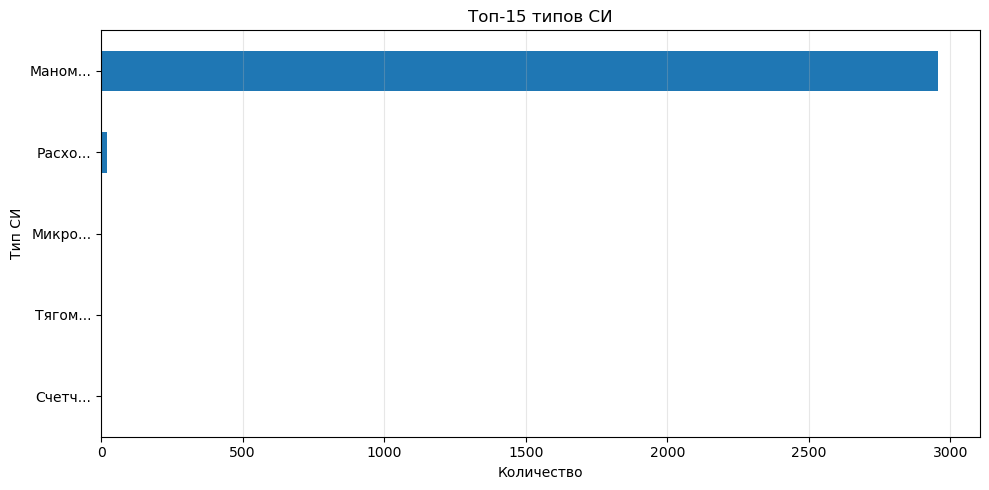


Организации-поверители (топ 15):


org_title_norm
ФЕДЕР...    2974
ОБЩЕС...       6
Федер...       2
Name: count, dtype: Int64

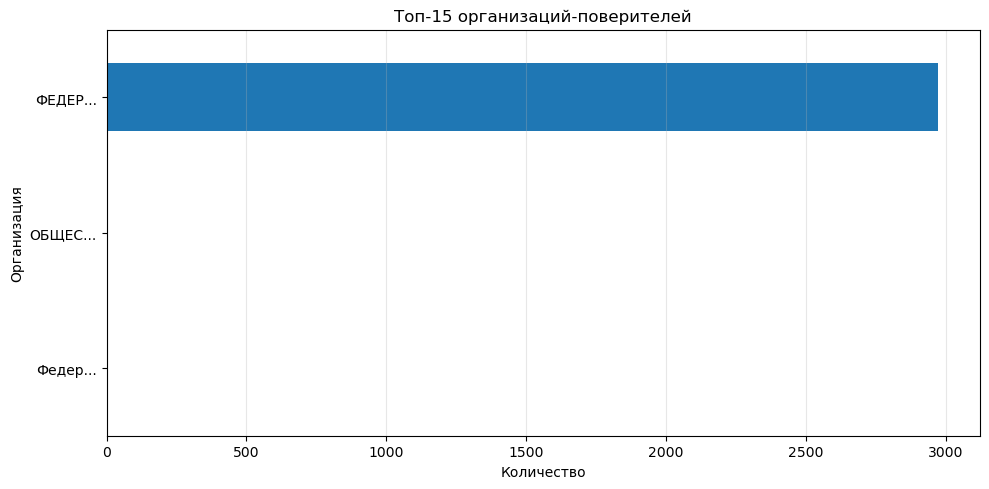


Владельцы СИ (топ 15):


owner_norm
-           1310
ФГУП ...     767
ФАУ &...     496
             273
Специ...     115
МАИ+3Н         8
НИИ П...       4
ИП Ба...       2
Индив...       2
ООО &...       1
ИП Ис...       1
Исмаи...       1
Магом...       1
МАНО ...       1
Name: count, dtype: Int64

In [54]:
import matplotlib.pyplot as plt

if df_dataset.empty:
    pass
else:
    print(f"Записей в датасете: {len(df_dataset)}")
    print(f"\nЗаписи по задачам:")
    display(df_dataset['task'].value_counts(dropna=False))

    if 'verification_year' in df_dataset.columns:
        print(f"\nДинамика по годам поверки (в разрезе задачи):")
        pivot_y = (
            df_dataset
            .dropna(subset=['verification_year'])
            .groupby(['task', 'verification_year'])
            .size()
            .reset_index(name='n')
            .sort_values(['task', 'verification_year'])
        )
        display(pivot_y)

        plt.figure(figsize=(10, 4))
        for task, g in pivot_y.groupby('task'):
            plt.plot(g['verification_year'], g['n'], marker='o', label=str(task))
        plt.title('Число поверок по годам')
        plt.xlabel('Год поверки')
        plt.ylabel('Количество записей')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

        if 'result_doc_type' in df_dataset.columns:
            by_year_result = (
                df_dataset
                .dropna(subset=['verification_year'])
                .groupby(['verification_year', 'result_doc_type'])
                .size()
                .unstack(fill_value=0)
                .sort_index()
            )
            top_cols = by_year_result.sum(axis=0).sort_values(ascending=False).head(6).index
            by_year_result = by_year_result.loc[:, top_cols]
            by_year_result.plot(kind='bar', stacked=True, figsize=(10, 4))
            plt.title('Результат поверки по годам (топ-6 категорий)')
            plt.xlabel('Год поверки')
            plt.ylabel('Количество')
            plt.grid(True, axis='y', alpha=0.3)
            plt.tight_layout()
            plt.show()

    if 'result_doc_type' in df_dataset.columns:
        print(f"\nРезультат поверки (топ):")
        display(df_dataset['result_doc_type'].value_counts(dropna=False).head(15))

    if 'mitypeTitle_norm' in df_dataset.columns:
        print(f"\nТип СИ (топ 15):")
        top_types = df_dataset['mitypeTitle_norm'].value_counts(dropna=False).head(15)
        display(top_types)

        plt.figure(figsize=(10, 5))
        top_types.sort_values().plot(kind='barh')
        plt.title('Топ-15 типов СИ')
        plt.xlabel('Количество')
        plt.ylabel('Тип СИ')
        plt.grid(True, axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()

    if 'org_title_norm' in df_dataset.columns:
        print(f"\nОрганизации-поверители (топ 15):")
        top_orgs = df_dataset['org_title_norm'].value_counts(dropna=False).head(15)
        display(top_orgs)

        plt.figure(figsize=(10, 5))
        top_orgs.sort_values().plot(kind='barh')
        plt.title('Топ-15 организаций-поверителей')
        plt.xlabel('Количество')
        plt.ylabel('Организация')
        plt.grid(True, axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()

    if 'owner_norm' in df_dataset.columns:
        print(f"\nВладельцы СИ (топ 15):")
        top_owners = df_dataset['owner_norm'].value_counts(dropna=False).head(15)
        display(top_owners)

    if 'poverka_valid_date' in df_dataset.columns:
        valid_date = df_dataset['poverka_valid_date']
        if valid_date.notna().any():
            today = pd.Timestamp.today().normalize()
            status = pd.Series(pd.NA, index=df_dataset.index, dtype='string')
            status[valid_date.notna() & (valid_date >= today)] = 'действительна'
            status[valid_date.notna() & (valid_date < today)] = 'просрочена'
            df_tmp = df_dataset.copy()
            df_tmp['validity_status'] = status

            print(f"\nСтатус действительности поверки (по poverka_valid_date):")
            display(df_tmp['validity_status'].value_counts(dropna=False))

            by_task_status = (
                df_tmp
                .groupby(['task', 'validity_status'])
                .size()
                .unstack(fill_value=0)
            )
            by_task_status.plot(kind='bar', stacked=True, figsize=(10, 4))
            plt.title('Действительность поверки по задачам')
            plt.xlabel('Задача')
            plt.ylabel('Количество')
            plt.grid(True, axis='y', alpha=0.3)
            plt.tight_layout()
            plt.show()

    if 'poverka_verification_date' in df_dataset.columns and 'poverka_publication_date' in df_dataset.columns:
        lag = (df_dataset['poverka_publication_date'] - df_dataset['poverka_verification_date']).dt.days
        lag = lag.dropna()
        if not lag.empty:
            plt.figure(figsize=(10, 4))
            plt.hist(lag.clip(lower=-30, upper=365), bins=40)
            plt.title('Лаг публикации относительно даты поверки')
            plt.xlabel('Дней')
            plt.ylabel('Частота')
            plt.grid(True, axis='y', alpha=0.3)
            plt.tight_layout()
            plt.show()

    if 'verification_month' in df_dataset.columns:
        print(f"\nДинамика по месяцам (если заполнена дата поверки):")
        by_m = (
            df_dataset
            .dropna(subset=['verification_month'])
            .groupby(['task', 'verification_month'])
            .size()
            .reset_index(name='n')
            .sort_values(['task', 'verification_month'])
        )
        display(by_m.head(30))

        tasks = by_m['task'].unique().tolist()
        for t0 in tasks[:2]:
            g = by_m[by_m['task'] == t0].copy()
            plt.figure(figsize=(10, 4))
            plt.plot(g['verification_month'], g['n'], marker='o')
            plt.title(f"Динамика по месяцам: {t0}")
            plt.xlabel('Месяц')
            plt.ylabel('Количество записей')
            plt.xticks(rotation=45, ha='right')
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()

Доля уникальных mitypeNumber по задачам


,rows,uniq_mitype,uniq_share
task,,,
mai_flowmeters,21,9,0.428571
tsagi_manometers,2961,57,0.019250


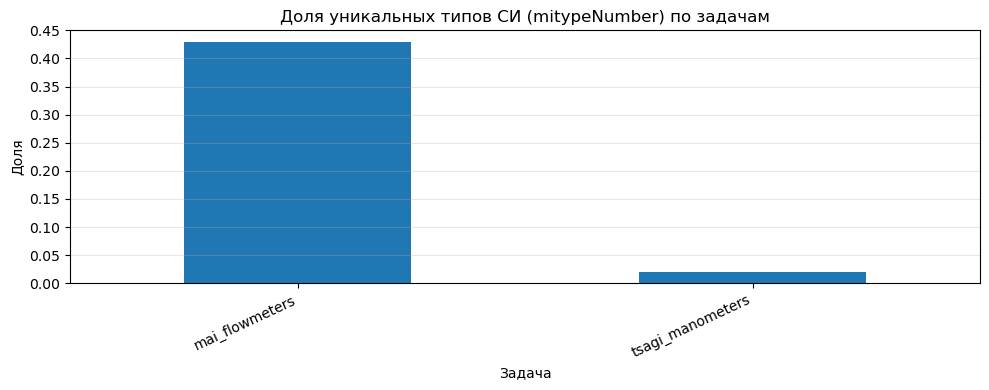

Топ-12 владельцев СИ


owner_norm
-           1310
ФГУП ...     767
ФАУ &...     496
             273
Специ...     115
МАИ+3Н         8
НИИ П...       4
ИП Ба...       2
Индив...       2
ООО &...       1
ИП Ис...       1
Исмаи...       1
Name: count, dtype: Int64

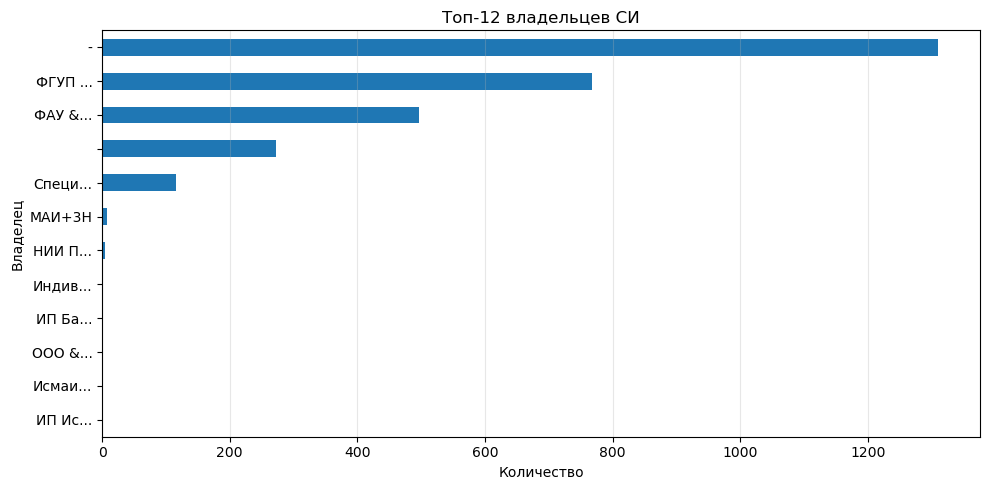

Топ-15 mitypeNumber


mitypeNumber
490-50      509
3255-72     279
4041-74     274
20680-07    193
10135-88    192
3383-72     181
1784-63     161
55984-13    140
25913-03    127
1844-63     106
10135-15     80
59554-14     77
47013-14     54
1778-63      47
25913-08     47
Name: count, dtype: Int64

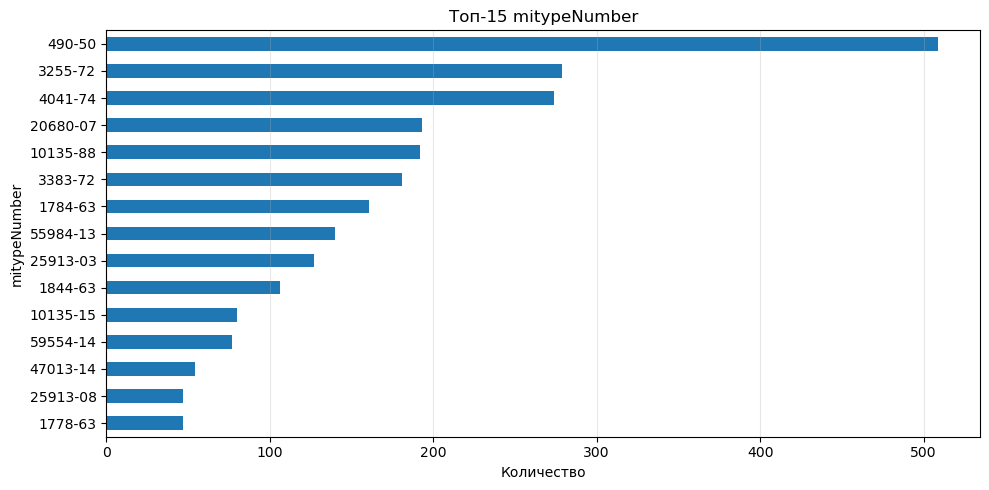

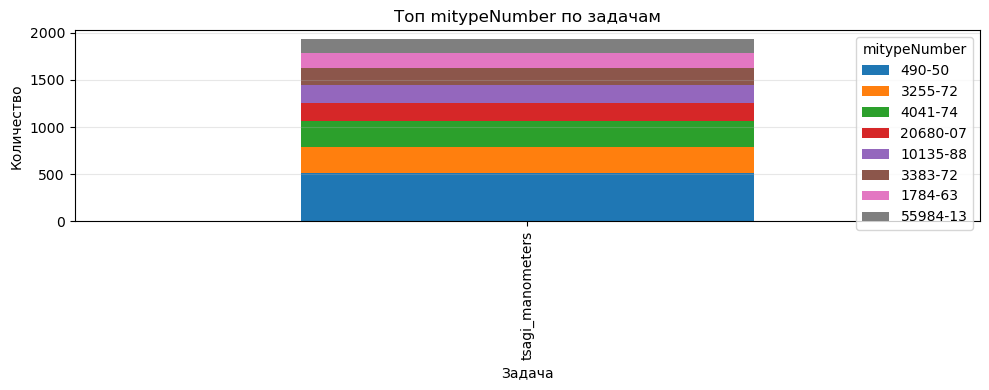

Разнообразие СИ по задачам


,unique_mitypeNumber,unique_mitypeTitle
mai_flowmeters,9,2
tsagi_manometers,57,3


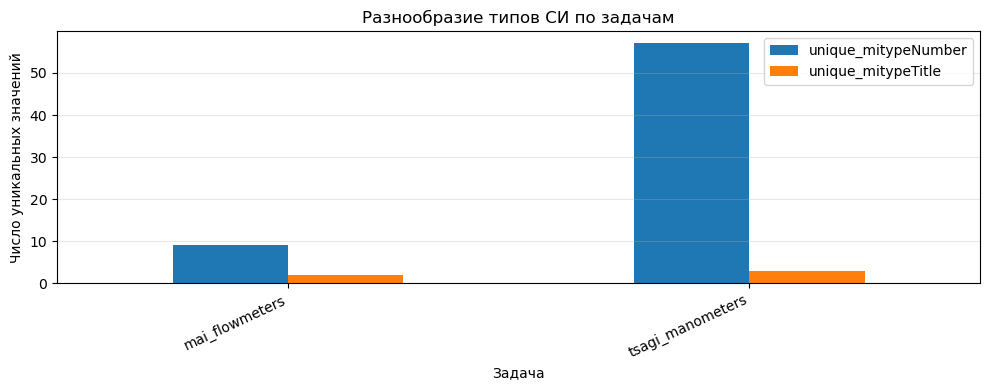

Топ-10 result_doc_type


result_doc_type
Извещение о непригодности    2982
Name: count, dtype: Int64

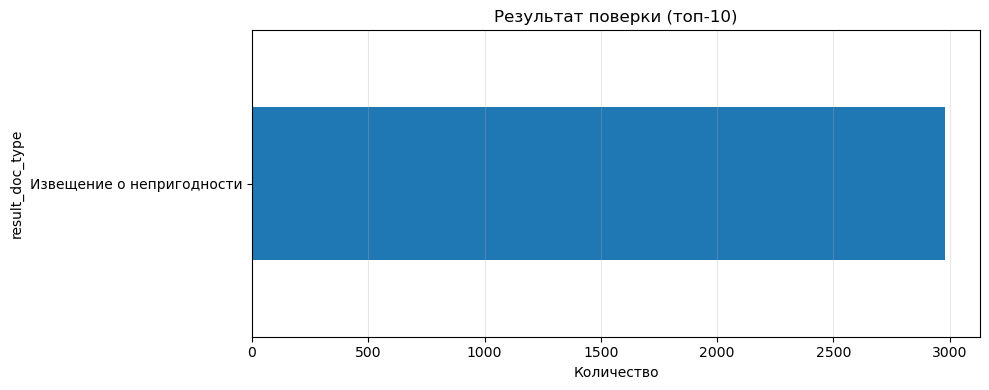

In [55]:
import matplotlib.pyplot as plt

if df_dataset.empty:
    print(f"Нет данных в df_dataset")
else:
    if 'task' in df_dataset.columns and 'mitypeNumber' in df_dataset.columns:
        uniq_share = (
            df_dataset
            .groupby('task')
            .agg(rows=('mitypeNumber', 'size'), uniq_mitype=('mitypeNumber', 'nunique'))
        )
        uniq_share['uniq_share'] = uniq_share['uniq_mitype'] / uniq_share['rows']
        uniq_share = uniq_share.sort_index()

        print(f"Доля уникальных mitypeNumber по задачам")
        display(uniq_share)

        plt.figure(figsize=(10, 4))
        uniq_share['uniq_share'].plot(kind='bar')
        plt.title('Доля уникальных типов СИ (mitypeNumber) по задачам')
        plt.xlabel('Задача')
        plt.ylabel('Доля')
        plt.grid(True, axis='y', alpha=0.3)
        plt.xticks(rotation=25, ha='right')
        plt.tight_layout()
        plt.show()

    if 'owner_norm' in df_dataset.columns:
        top_owner = df_dataset['owner_norm'].astype('string').value_counts(dropna=False).head(12)
        print(f"Топ-12 владельцев СИ")
        display(top_owner)
        plt.figure(figsize=(10, 5))
        top_owner.sort_values().plot(kind='barh')
        plt.title('Топ-12 владельцев СИ')
        plt.xlabel('Количество')
        plt.ylabel('Владелец')
        plt.grid(True, axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()
    if 'mitypeNumber' in df_dataset.columns:
        top_mn = df_dataset['mitypeNumber'].astype('string').value_counts(dropna=False).head(15)
        print(f"Топ-15 mitypeNumber")
        display(top_mn)
        plt.figure(figsize=(10, 5))
        top_mn.sort_values().plot(kind='barh')
        plt.title('Топ-15 mitypeNumber')
        plt.xlabel('Количество')
        plt.ylabel('mitypeNumber')
        plt.grid(True, axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()

        if 'task' in df_dataset.columns:
            top_keys = top_mn.index.tolist()[:8]
            tmp = df_dataset[df_dataset['mitypeNumber'].astype('string').isin(top_keys)].copy()
            if not tmp.empty:
                ct = tmp.groupby(['task', tmp['mitypeNumber'].astype('string')]).size().unstack(fill_value=0)
                ct = ct.loc[:, top_keys]
                ct.plot(kind='bar', stacked=True, figsize=(10, 4))
                plt.title('Топ mitypeNumber по задачам')
                plt.xlabel('Задача')
                plt.ylabel('Количество')
                plt.grid(True, axis='y', alpha=0.3)
                plt.tight_layout()
                plt.show()

    if 'task' in df_dataset.columns:
        metrics = pd.DataFrame(index=df_dataset['task'].astype('string').unique())

        if 'mitypeNumber' in df_dataset.columns:
            metrics['unique_mitypeNumber'] = df_dataset.groupby('task')['mitypeNumber'].nunique(dropna=True)

        if 'mitypeTitle_norm' in df_dataset.columns:
            metrics['unique_mitypeTitle'] = df_dataset.groupby('task')['mitypeTitle_norm'].nunique(dropna=True)

        if not metrics.empty:
            metrics = metrics.sort_index()
            print(f"Разнообразие СИ по задачам")
            display(metrics)

            ax = metrics.plot(kind='bar', figsize=(10, 4))
            ax.set_title('Разнообразие типов СИ по задачам')
            ax.set_xlabel('Задача')
            ax.set_ylabel('Число уникальных значений')
            ax.grid(True, axis='y', alpha=0.3)
            plt.xticks(rotation=25, ha='right')
            plt.tight_layout()
            plt.show()

    if 'result_doc_type' in df_dataset.columns:
        top_r = df_dataset['result_doc_type'].astype('string').value_counts(dropna=False).head(10)
        print(f"Топ-10 result_doc_type")
        display(top_r)
        plt.figure(figsize=(10, 4))
        top_r.sort_values().plot(kind='barh')
        plt.title('Результат поверки (топ-10)')
        plt.xlabel('Количество')
        plt.ylabel('result_doc_type')
        plt.grid(True, axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()

    if 'poverka_verification_date' in df_dataset.columns and 'poverka_publication_date' in df_dataset.columns and 'task' in df_dataset.columns:
        lag = (df_dataset['poverka_publication_date'] - df_dataset['poverka_verification_date']).dt.days
        tmp = df_dataset.loc[lag.notna(), ['task']].copy()
        tmp['lag_days'] = lag[lag.notna()].astype(int)
        tmp = tmp[(tmp['lag_days'] >= -30) & (tmp['lag_days'] <= 365)]
        if not tmp.empty:
            groups = [g['lag_days'].to_numpy() for _, g in tmp.groupby('task')]
            labels = [str(k) for k, _ in tmp.groupby('task')]
            plt.figure(figsize=(10, 4))
            plt.boxplot(groups, labels=labels, showfliers=False)
            plt.title('Лаг публикации по задачам (boxplot, дни)')
            plt.xlabel('Задача')
            plt.ylabel('Дней')
            plt.grid(True, axis='y', alpha=0.3)
            plt.tight_layout()
            plt.show()
            med = tmp.groupby('task')['lag_days'].median().sort_values(ascending=False)
            print(f"Медианный лаг (дни) по задачам")
            display(med)
